# Beaver Simulation - Rumney Ranch, Montana

This notebook runs a multi-agent beaver simulation on DEM (Digital Elevation Model) data from Rumney Ranch, Montana.

## Quick Start

1. Run Cell 1 to set up the project import path.
2. Review and adjust Cell 2 (`beavers_running_config`).
3. Run Cell 3 to start the simulation.

## Configuration Reference (Cell 2)

### Top-Level
- **backend_type**: Agent-environment backend (`'beavers_visualizer'`).

### environment
- **name**: Environment backend name (`'beavers_environment'`).
- **elevation_file_path**: Path to elevation raster (`.npy`).
- **latitude_file_path**: Path to latitude grid (`.npy`).
- **longitude_file_path**: Path to longitude grid (`.npy`).
- **vegetation_quality_range**: `[min, max]` bounds for vegetation values.
- **grass_growth_interval**: Elevation interval where grass can grow.
- **grass_growth_rate**: Baseline vegetation growth rate.
- **grass_growth_sigma**: Stochastic variability of growth.
- **mean_reversion_strength**: Pull toward seasonal baseline.
- **visits_reset**: Decay factor applied to visit counts each step.
- **flow_info**: Water dynamics settings.
  - **river_growth_velocity**: River deepening rate over time.
  - **river_growth_interval**: Elevation interval where river growth applies.
  - **streams_depth**: Water depth threshold parameter.
  - **direction**: Flow direction vector `[x, y]`.
  - **strength**: Flow strength affecting movement.
- **print**: Enable/disable environment debug logs.

### robot
- **home_base_position**: Beaver lodge coordinate(s) `[[x, y]]`.
- **maximum_load**: Max carried load before return behavior.
- **harvest_interval**: Vegetation range where harvesting is allowed.
- **epsilon_greedy**: Exploration probability for epsilon-greedy policy.
- **exploration_eta**: Exploration randomness scale.
- **decay_values**: Adaptive decay values `[eta, harvest_interval, max_load]`.
- **role**: Agent role (`'explorer'` or `'builder'`).
- **controller**: Motion controller settings.
  - **name**: Controller type (`'P_repulsive'`).
  - **Kp, Kd, Ki**: PID gains.
  - **neighbourhood_size**: Local neighborhood size for repulsion.
  - **max**: Maximum movement speed.
  - **accuracy**: Position tolerance.
  - **dimension**: State-space dimension (2D).
  - **map_repulsive**: Repulsive potential source map.
  - **beta_repulsive**: Repulsion intensity.
- **dynamics**: Motion model parameters.
  - **name**: Dynamics model (`'integrator'`).
  - **mass**: Agent mass.
  - **friction**: Friction coefficient.
- **vegetation_removal**: Vegetation removed per harvest action.
- **visit_increase**: Visit-count increment per action.
- **exploration_map**: Exploration target map (`'vegetation_quality'` or `'vegetation_visits'`).
- **print**: Enable/disable robot debug logs.

### simulation
- **seed**: Random seed for reproducibility.
- **timedelta**: Simulation time step (hours).
- **schedule_policy**: Agent scheduling policy (`'sequential'`).
- **gui**: Enable simulation visualizer.
- **number_of_agents**: Number of beaver agents.
- **number_of_steps**: Total simulation steps.
- **downsampling**: Snapshot interval in steps.
- **save_path**: Output folder for snapshots/results.
- **print**: Enable simulation progress logs.

## Notes
- In Python dictionaries, duplicate keys keep the last assignment. In this config, the second `save_path` value is the one used at runtime.
- No additional parameters are documented here beyond what is currently set in Cell 2.

## Step 1 - Workspace Setup

Prepare imports and ensure the project root is on Python path.

In [1]:
# Setup: Add parent directory to Python path to import beaversim modules# Apply Gaussian blur to all images (increase/decrease sigma for stronger/weaker smoothing)
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'beaversim').is_dir():
        project_root = parent
        break
else:
    raise RuntimeError("Could not locate project root containing 'beaversim'.")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root: {project_root}")
print(f"Python path updated to include: {project_root}")

Project root: /home/fedeoli/Documents/Projects/BeaverSim
Python path updated to include: /home/fedeoli/Documents/Projects/BeaverSim


## Step 2 - Simulation Configuration

Define beavers_running_config with environment, robot, and simulation parameters.

In [2]:
from beaversim.scenarios.standard_beavers_scenario import standard_beavers_scenario

# ============================================================================
# BEAVER SIMULATION CONFIGURATION - RUMNEY RANCH, MONTANA
# ============================================================================

beavers_running_config = {
    # Agent-Environment coupling backend
    'backend_type': 'beavers_visualizer',
    
    # ========================================================================
    # ENVIRONMENT CONFIGURATION
    # ========================================================================
    'environment': {
        'name': 'beavers_environment',
        
        # --- Data Files (RGB outputs from utils/dem_conversion_interactive.ipynb) ---
        'elevation_file_path': '../../output/RumneyRanch_Montana/RGB/A2/raw/baseline_matrix.npy',
        'latitude_file_path': '../../output/RumneyRanch_Montana/RGB/A2/raw/X_coordinates.npy',
        'longitude_file_path': '../../output/RumneyRanch_Montana/RGB/A2/raw/Y_coordinates.npy',
        'metadata_file_path': '../../output/RumneyRanch_Montana/RGB/A2/raw/processing_metadata.json',
        
        # --- Vegetation Dynamics ---
        'vegetation_quality_range': [0, 10],
        'grass_growth_interval': [0, 8],
        'grass_growth_rate': 1*1e-4,
        'grass_growth_sigma': 0.5,
        'mean_reversion_strength' : 0.0005,
        
        # --- Visitation Dynamics ---
        'visits_reset': 0.99,
        
        # --- Water/River Dynamics ---
        'flow_info': {
            'river_growth_velocity': 1e-4,
            'river_growth_interval': [-3, 0],
            'streams_depth': 10,
            'direction': [1, 1],
            'strength': 0.2,
        },
        
        'print': False,
    },
    
    # ========================================================================
    # BEAVER (ROBOT) CONFIGURATION
    # ========================================================================
    'robot': {   
        
        # --- Initial Position ---        
        'home_base_position': [[60, 60]],
        
        # -- Agent Cognitive and Behavioral Parameters 
        'maximum_load': [1000, 10],
        'harvest_interval': [[6, 9], [0, 3]],
        'epsilon_greedy': [0.8, 1.0],
        'exploration_map': ['vegetation_quality', 'vegetation_visits'], 
        'vegetation_removal': [1*3.0, 1*1.0],               
        'role': ['explorer', 'builder'],
        
        # -- Dynamic Control and Model Parameters 
        'controller': {
            'name': 'P_repulsive',
            'Kp': 0.5,
            'Kd': 2.0,
            'Ki': 1e-5,
            'neighbourhood_size': 2,
            'accuracy': 5e-1,
            'map_repulsive': 'vegetation_quality',
            'beta_repulsive': 0.2,
        },
        # --- Physics Model ---
        'dynamics': {
            'name': 'integrator',
            'mass': 5,
            'friction': 1,
        },
        
        # -- Environmental and Stigmergic Coupling Parameters         
        'visit_increase': 1.0,    
        'decay_values': [0.001, 0.001],
        
        # Miscellaneous                        
        'print': False,
    },
    
    # ========================================================================
    # SIMULATION CONFIGURATION
    # ========================================================================
    'simulation': {
        'seed': 20,
        'timedelta': 1.0,
        'schedule_policy': 'sequential',
        'gui': True,
        'number_of_agents': 4,
        'number_of_steps': 365 * 4,
        'downsampling': 30,
        'save_path': '../../output/simulations/rumney_ranch_demo/REV_4_agents_4_year',
        'print': True,
    },
}

## Step 3 - Run Scenario

Instantiate and run the Rumney Ranch scenario using the current configuration.

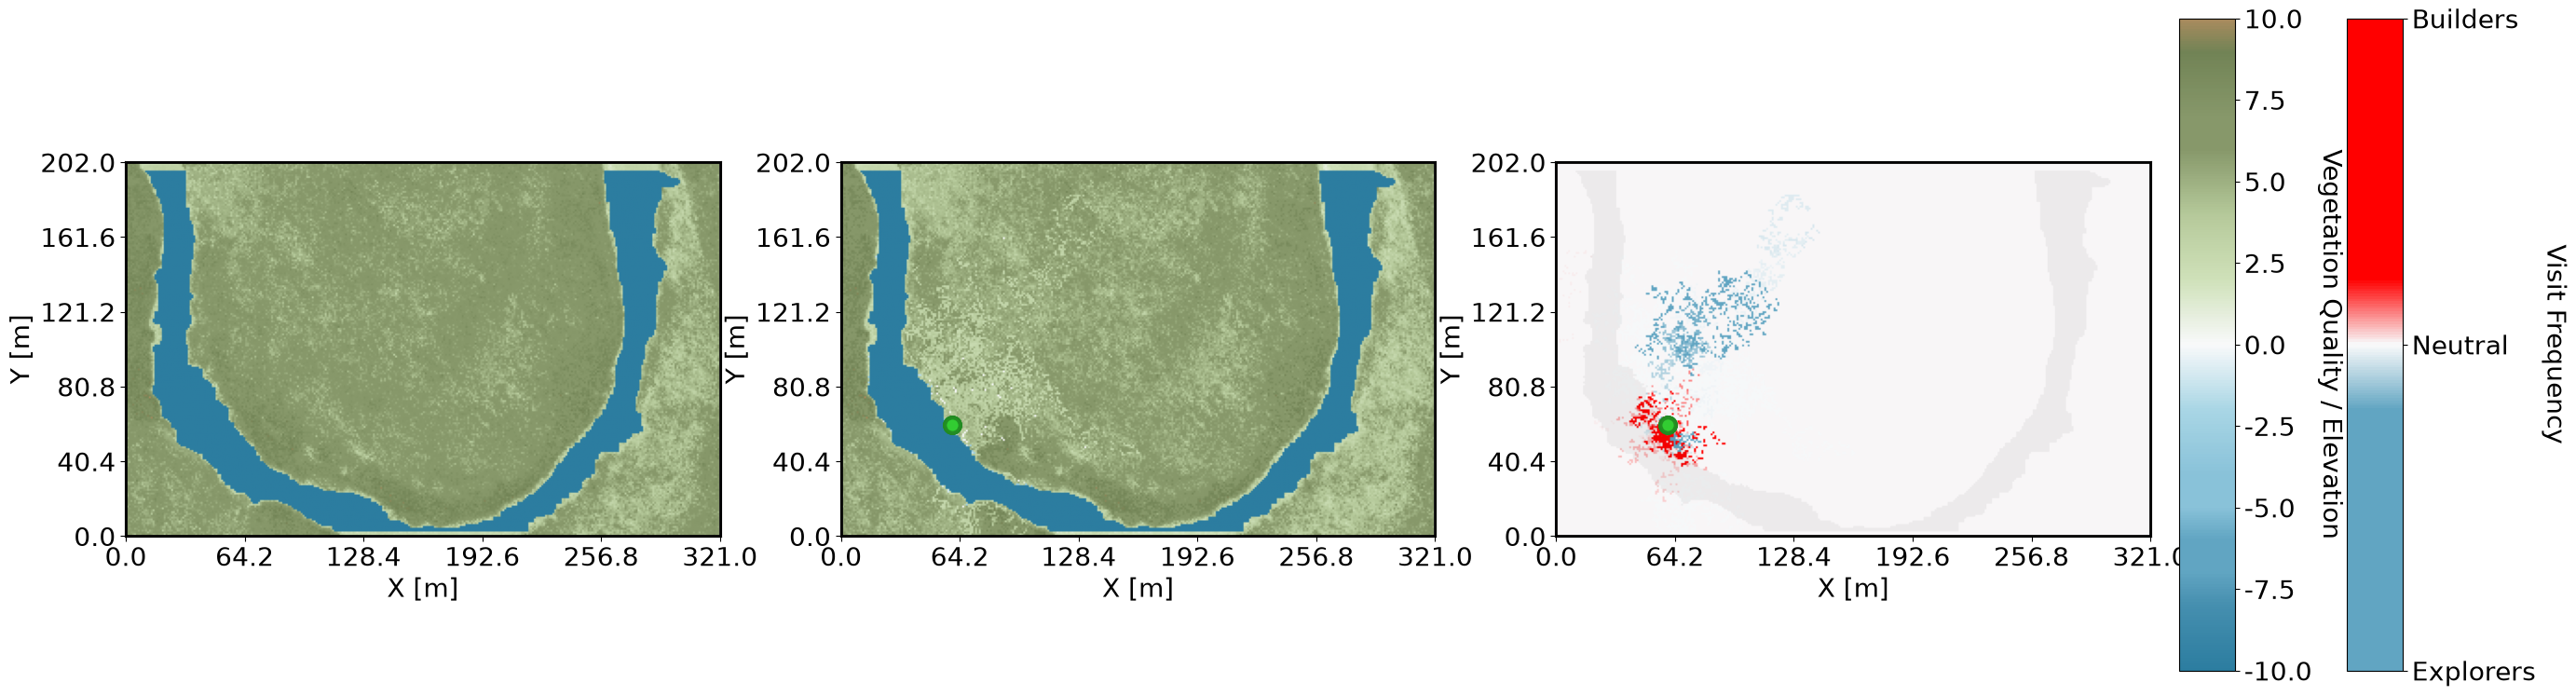

Environment map saved to: ../../output/simulations/rumney_ranch_demo/REV_4_agents_4_year
Original map shape (environment format): (321, 202)
Saved map shape: (202, 321)
Original value range: [-10.000, 10.000]
Saved value range: [-1.000, 1.000]
[-10.000, 10.000] -> [-1.0, 1.0]
Backend state saved to: ../../output/simulations/rumney_ranch_demo/REV_4_agents_4_year/final_backend.pkl.gz


In [3]:
back = standard_beavers_scenario(beavers_running_config)